In [ ]:
!pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 69.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires 

In [ ]:
!pip install roboticstoolbox-python spatialmath-python -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.8/193.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import roboticstoolbox as rtb
import numpy as np
import pandas as pd

ur3 = rtb.models.UR3()
print("Success!")

Success!


In [ ]:
import roboticstoolbox as rtb
import spatialmath as sm
import numpy as np
import pandas as pd

# 1. Load the built-in UR3 kinematic model
ur3 = rtb.models.UR3()

num_samples = 2_000_000
dataset = []

print("Generating continuous FK data for Neural Network training...")

for _ in range(num_samples):
    # Generate random joint angles within the UR3's physical limits
    q_rand = ur3.random_q()

    # Calculate Forward Kinematics
    fk_matrix = ur3.fkine(q_rand)

    # ---------------------------------------------------------
    # INPUT FIX: Cartesian Position & Quaternions
    # ---------------------------------------------------------
    # Extract Tool Position (X, Y, Z) in meters
    x, y, z = fk_matrix.t

    # Extract Tool Orientation as a Quaternion (qw, qx, qy, qz)
    # The .vec property returns a 1D array of the 4 quaternion values
    quat = sm.UnitQuaternion(fk_matrix.R).vec
    qw, qx, qy, qz = quat[0], quat[1], quat[2], quat[3]

    # ---------------------------------------------------------
    # OUTPUT FIX: Continuous Sine and Cosine waves
    # ---------------------------------------------------------
    sin_q = np.sin(q_rand)
    cos_q = np.cos(q_rand)

    # Create a single row: 3 Pos + 4 Quat + 6 Sin + 6 Cos = 19 total columns
    row = [x, y, z, qw, qx, qy, qz] + sin_q.tolist() + cos_q.tolist()
    dataset.append(row)

# Define clean column headers
pos_cols = ['x', 'y', 'z']
quat_cols = ['qw', 'qx', 'qy', 'qz']
joints = ['base', 'shoulder', 'elbow', 'wrist1', 'wrist2', 'wrist3']
sin_cols = [f'sin_{j}' for j in joints]
cos_cols = [f'cos_{j}' for j in joints]

columns = pos_cols + quat_cols + sin_cols + cos_cols

# Save to CSV
df = pd.DataFrame(dataset, columns=columns)
output_filename = "ur3_fk_continuous_dataset.csv"
df.to_csv(output_filename, index=False)

print(f"Dataset successfully saved to {output_filename}")

Generating continuous FK data for Neural Network training...
multiple end-effectors present, ambiguous, using self.ee_links[0]
Dataset successfully saved to ur3_fk_continuous_dataset.csv


 UR3 DATASET EVALUATION
Total Samples Generated: 656537

Cartesian Workspace Bounds (Meters):
X reach: -0.583 to 0.583
Y reach: -0.585 to 0.585
Z reach: -0.423 to 0.726



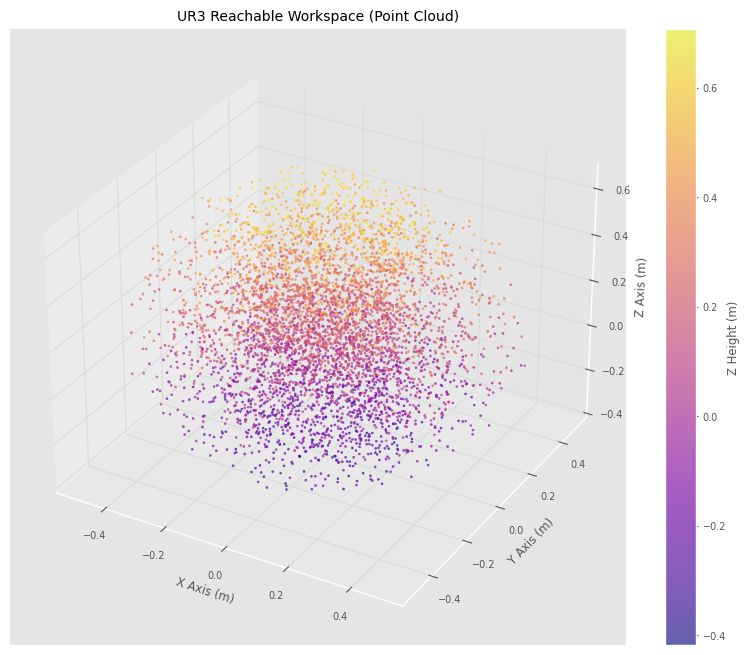

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# 1. Load the dataset
filename = "ur3_fk_continuous_dataset.csv"
df = pd.read_csv(filename)

print("="*40)
print(" UR3 DATASET EVALUATION")
print("="*40)

# 2. Check basic bounds and reachability
# The UR3 has a reach radius of ~0.5 meters (500mm)
print(f"Total Samples Generated: {len(df)}")
print("\nCartesian Workspace Bounds (Meters):")
print(f"X reach: {df['x'].min():.3f} to {df['x'].max():.3f}")
print(f"Y reach: {df['y'].min():.3f} to {df['y'].max():.3f}")
print(f"Z reach: {df['z'].min():.3f} to {df['z'].max():.3f}")

# Check for any missing values just to be safe
if df.isnull().values.any():
    print("\nWARNING: NaN values detected in the dataset!")
else:
    print("\nData integrity check passed: No missing values.")

# ==========================================
# Plot 1: 3D Reachable Workspace
# ==========================================
# We sample down to 5,000 points just so the 3D plot doesn't lag your computer
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Color mapping based on Z-height for better depth perception
scatter = ax.scatter(sample_df['x'], sample_df['y'], sample_df['z'],
                     c=sample_df['z'], cmap='plasma', s=2, alpha=0.6)

ax.set_title('UR3 Reachable Workspace (Point Cloud)')
ax.set_xlabel('X Axis (m)')
ax.set_ylabel('Y Axis (m)')
ax.set_zlabel('Z Axis (m)')
fig.colorbar(scatter, label='Z Height (m)')

# Force equal aspect ratio so the "sphere" of reach doesn't look squished
max_range = np.array([sample_df['x'].max()-sample_df['x'].min(),
                      sample_df['y'].max()-sample_df['y'].min(),
                      sample_df['z'].max()-sample_df['z'].min()]).max() / 2.0
mid_x = (sample_df['x'].max()+sample_df['x'].min()) * 0.5
mid_y = (sample_df['y'].max()+sample_df['y'].min()) * 0.5
mid_z = (sample_df['z'].max()+sample_df['z'].min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.show()

 CONTINUOUS DATASET POSE VISUALIZATION
Cartesian Target (X, Y, Z): -0.141, 0.075, 0.060 meters
Quaternion (qw, qx, qy, qz): 0.528, 0.244, 0.186, 0.792
Euler Equivalent (rx, ry, rz): 0.596, -0.191, 1.907 rads
Reconstructed Joint Angles: [ 1.374 -2.853 -2.974 -0.677  1.049 -2.434] rads


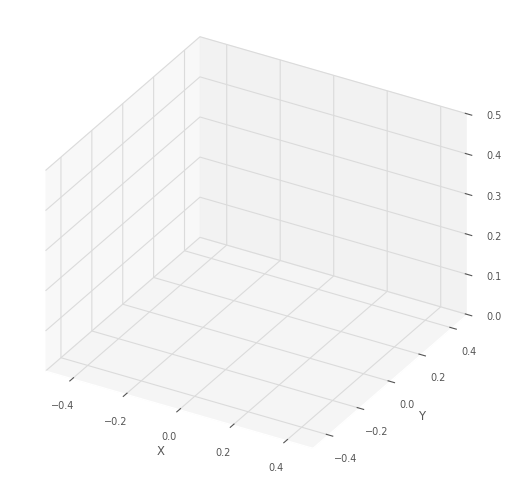

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'UR3')

In [ ]:
# %matplotlib widget
import pandas as pd
import roboticstoolbox as rtb
import spatialmath as sm
import numpy as np

# 1. Load the NEW dataset
df = pd.read_csv("ur3_fk_continuous_dataset.csv")

# 2. Select a single random sample
sample = df.sample(1).iloc[0]

# 3. Reconstruct the 6 joint angles from Sine and Cosine
joints = ['base', 'shoulder', 'elbow', 'wrist1', 'wrist2', 'wrist3']
q_sample = []

for j in joints:
    # np.arctan2(y, x) handles the 360-degree mapping perfectly
    # We pass it our saved sin (y) and cos (x)
    angle = np.arctan2(sample[f'sin_{j}'], sample[f'cos_{j}'])
    q_sample.append(angle)

q_sample = np.array(q_sample)

# 4. Extract Cartesian and Quaternion targets for printing
x, y, z = sample['x'], sample['y'], sample['z']
quat = [sample['qw'], sample['qx'], sample['qy'], sample['qz']]

# Optional: Convert the Quaternion back to Euler just for human-readable printing
# (Your neural network doesn't need this, but it makes it easier for us to read)
rpy = sm.UnitQuaternion(quat).rpy('rad')

print("="*50)
print(" CONTINUOUS DATASET POSE VISUALIZATION")
print("="*50)
print(f"Cartesian Target (X, Y, Z): {x:.3f}, {y:.3f}, {z:.3f} meters")
print(f"Quaternion (qw, qx, qy, qz): {quat[0]:.3f}, {quat[1]:.3f}, {quat[2]:.3f}, {quat[3]:.3f}")
print(f"Euler Equivalent (rx, ry, rz): {rpy[0]:.3f}, {rpy[1]:.3f}, {rpy[2]:.3f} rads")
print(f"Reconstructed Joint Angles: {np.round(q_sample, 3)} rads")

# 5. Load the UR3 model and plot it
ur3 = rtb.models.UR3()

# Note: If you are still running this in Google Colab,
# remember to use the %matplotlib widget magic command and set block=False!
ur3.plot(q_sample, backend='pyplot', block=False)

In [ ]:
q_sample

array([ 1.37423398, -2.8526282 , -2.9743267 , -0.67735752,  1.04856252,
       -2.43358762])

In [ ]:
ur3 = rtb.models.UR3()
print(ur3)

ERobot: UR3 (by Universal Robotics), 6 joints (RRRRRR), 3 branches, dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────────────┬──────────────────────────────────────────┐
│ link │      link      │ joint │     parent     │           ETS: parent to link            │
├──────┼────────────────┼───────┼────────────────┼──────────────────────────────────────────┤
│    0 │ world          │       │ BASE           │ SE3()                                    │
│    1 │ base_link      │       │ world          │ SE3()                                    │
│    2 │ shoulder_link  │     0 │ base_link      │ SE3(0, 0, 0.1519) ⊕ Rz(q0)               │
│    3 │ upper_arm_link │     1 │ shoulder_link  │ SE3(0, 0.1198, 0; 0°, 90°, -0°) ⊕ Ry(q1) │
│    4 │ forearm_link   │     2 │ upper_arm_link │ SE3(0, -0.0925, 0.2437) ⊕ Ry(q2)         │
│    5 │ wrist_1_link   │     3 │ forearm_link   │ SE3(0, 0, 0.2132; 0°, 90°, -0°) ⊕ Ry(q3) │
│    6 │ wrist_2_link   │     4 │ wrist_1_link   │ SE3(0

In [ ]:
# 1. Authorize custom widgets in Google Colab
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# ==========================================
# 1. SPECIALIZED UR3 DATASET LOADER
# ==========================================
class UR3KinematicsDataset(Dataset):
    def __init__(self, csv_file):
        # Load the CSV generated by your script
        df = pd.read_csv(csv_file)

        # Inputs to Inverse Model / Targets for Forward Model (7 columns)
        self.poses = torch.tensor(
            df[['x', 'y', 'z', 'qw', 'qx', 'qy', 'qz']].values,
            dtype=torch.float32
        )

        # Targets for Inverse Model / Inputs to Forward Model (12 columns)
        joints_sin_cos = [
            'sin_base', 'sin_shoulder', 'sin_elbow', 'sin_wrist1', 'sin_wrist2', 'sin_wrist3',
            'cos_base', 'cos_shoulder', 'cos_elbow', 'cos_wrist1', 'cos_wrist2', 'cos_wrist3'
        ]
        self.joints = torch.tensor(df[joints_sin_cos].values, dtype=torch.float32)

    def __len__(self):
        return len(self.poses)

    def __getitem__(self, idx):
        return self.joints[idx], self.poses[idx]

class KinematicsResidualBlock(nn.Module):
    """
    A foundational residual building block with LayerNorm and Skip Connections
    to preserve high-frequency coordinate data across deep layers.
    """
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.ln1 = nn.LayerNorm(dim)
        self.fc2 = nn.Linear(dim, dim)
        self.ln2 = nn.LayerNorm(dim)

    def forward(self, x):
        residual = x
        out = F.relu(self.ln1(self.fc1(x)))
        out = self.ln2(self.fc2(out))
        out += residual  # Skip connection
        return F.relu(out)

# ==========================================
# SCALED DISCRETE CVAE ARCHITECTURE FOR UR3
# ==========================================

class UR3JointEncoder(nn.Module):
    """
    Pure CVAE Encoder: Maps 12D joint waves -> Outputs 8D Posture Mode Logits.
    No redundant coordinate prediction.
    """
    def __init__(self, joint_dim=12, num_classes=8, hidden_dim=512):
        super().__init__()

        # Project low-dimensional inputs up to the high-capacity feature space
        self.input_projection = nn.Sequential(
            nn.Linear(joint_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        # Deep residual core configuration
        self.res_layers = nn.Sequential(
            KinematicsResidualBlock(hidden_dim),
            KinematicsResidualBlock(hidden_dim),
            KinematicsResidualBlock(hidden_dim)
        )

        # Single dedicated output head for posture recognition
        self.latent_head = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, joints_continuous):
        x = self.input_projection(joints_continuous)
        x = self.res_layers(x)
        z_logits = self.latent_head(x)
        return z_logits

class DifferentiableUR3FK(nn.Module):
    """
    A fully differentiable, analytical Forward Kinematics layer for the UR3.
    Uses standard DH parameters, but initialized with a 180-degree base rotation
    to perfectly match the roboticstoolbox coordinate frame.
    """
    def __init__(self):
        super().__init__()
        # Standard DH parameter definitions for UR3: [alpha, a, d]
        self.register_buffer('alpha', torch.tensor([np.pi/2, 0.0, 0.0, np.pi/2, -np.pi/2, 0.0]))
        self.register_buffer('a', torch.tensor([0.0, -0.24365, -0.21325, 0.0, 0.0, 0.0]))
        self.register_buffer('d', torch.tensor([0.1519, 0.0, 0.0, 0.11235, 0.08535, 0.0819]))

    def forward(self, q):
        batch_size = q.size(0)
        device = q.device

        # ==========================================
        # THE FIX: Initialize with a 180-degree Z-axis flip
        # This instantly aligns the PyTorch space with roboticstoolbox!
        # ==========================================
        T = torch.eye(4, device=device).unsqueeze(0).repeat(batch_size, 1, 1)
        T[:, 0, 0] = -1.0  # Flips the X axis
        T[:, 1, 1] = -1.0  # Flips the Y axis

        for i in range(6):
            theta = q[:, i]
            alpha = self.alpha[i]
            a = self.a[i]
            d = self.d[i]

            ct = torch.cos(theta)
            st = torch.sin(theta)
            ca = torch.cos(alpha)
            sa = torch.sin(alpha)

            # Construct the transformation matrix A_i for the current link
            T_i = torch.zeros(batch_size, 4, 4, device=device)

            T_i[:, 0, 0] = ct
            T_i[:, 0, 1] = -st * ca
            T_i[:, 0, 2] = st * sa
            T_i[:, 0, 3] = a * ct

            T_i[:, 1, 0] = st
            T_i[:, 1, 1] = ct * ca
            T_i[:, 1, 2] = -ct * sa
            T_i[:, 1, 3] = a * st

            T_i[:, 2, 1] = sa
            T_i[:, 2, 2] = ca
            T_i[:, 2, 3] = d

            T_i[:, 3, 3] = 1.0

            # Chain transformations sequentially via batched matrix multiplication
            T = torch.bmm(T, T_i)

        T_tool = torch.zeros(batch_size, 4, 4, device=device)
        T_tool[:, 0, 1] = -1.0
        T_tool[:, 1, 2] = -1.0
        T_tool[:, 2, 0] = 1.0
        T_tool[:, 3, 3] = 1.0

        T = torch.bmm(T, T_tool)

        # Extract the final translation components [X, Y, Z] from the matrix
        pos = T[:, :3, 3]
        rot = T[:, :3, :3]
        return pos, rot

def quat_to_rot_matrix(quat):
    """
    Differentiable conversion from quaternion [qw, qx, qy, qz] to a 3x3 Rotation Matrix.
    """
    w, x, y, z = quat[:, 0], quat[:, 1], quat[:, 2], quat[:, 3]

    R = torch.zeros((quat.size(0), 3, 3), device=quat.device)

    R[:, 0, 0] = 1.0 - 2.0 * (y**2 + z**2)
    R[:, 0, 1] = 2.0 * (x*y - z*w)
    R[:, 0, 2] = 2.0 * (x*z + y*w)

    R[:, 1, 0] = 2.0 * (x*y + z*w)
    R[:, 1, 1] = 1.0 - 2.0 * (x**2 + z**2)
    R[:, 1, 2] = 2.0 * (y*z - x*w)

    R[:, 2, 0] = 2.0 * (x*z - y*w)
    R[:, 2, 1] = 2.0 * (y*z + x*w)
    R[:, 2, 2] = 1.0 - 2.0 * (x**2 + y**2)

    return R

class UR3ForwardModel(nn.Module):
    """
    Deep Residual Encoder: Maps 12D joint waves -> Outputs 7D Pose + 8D Posture Mode Logits.
    Increased hidden capacity to 512 units with nested skip layers.
    """
    def __init__(self, joint_dim=12, pos_dim=7, num_classes=8, hidden_dim=512):
        super().__init__()

        # Project low-dimensional inputs up to the high-capacity feature space
        self.input_projection = nn.Sequential(
            nn.Linear(joint_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        # Deep residual core configuration
        self.res_layers = nn.Sequential(
            KinematicsResidualBlock(hidden_dim),
            KinematicsResidualBlock(hidden_dim),
            KinematicsResidualBlock(hidden_dim),
            KinematicsResidualBlock(hidden_dim),
            KinematicsResidualBlock(hidden_dim)
        )

        # Output bottlenecks
        self.feature_bottleneck = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU()
        )

        self.pos_head = nn.Linear(256, pos_dim)
        self.latent_head = nn.Linear(256, num_classes)

    def forward(self, joints_continuous):
        x = self.input_projection(joints_continuous)
        x = self.res_layers(x)
        features = self.feature_bottleneck(x)

        pose_pred = self.pos_head(features)

        # Maintain valid structural unit quaternions (indices 3 to 7)
        pos, quat = pose_pred[:, :3], pose_pred[:, 3:]
        quat = F.normalize(quat, p=2, dim=-1)
        pose_pred = torch.cat([pos, quat], dim=-1)

        z_logits = self.latent_head(features)
        return pose_pred, z_logits


class UR3InverseModel(nn.Module):
    """
    Deep Residual Decoder: Takes 7D target pose + 8D discrete posture one-hot -> Outputs 12D joint waves.
    Expanded network depth to handle complex multi-solution coordinate crossings.
    """
    def __init__(self, pos_dim=7, num_classes=8, joint_dim=12, hidden_dim=512):
        super().__init__()

        # Input layer handling joint embedding + condition concatenation
        self.input_projection = nn.Sequential(
            nn.Linear(pos_dim + num_classes, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        # Core geometric mapping network
        self.res_layers = nn.Sequential(
            KinematicsResidualBlock(hidden_dim),
            KinematicsResidualBlock(hidden_dim),
            KinematicsResidualBlock(hidden_dim),
            KinematicsResidualBlock(hidden_dim),
            KinematicsResidualBlock(hidden_dim),
            KinematicsResidualBlock(hidden_dim)
        )

        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Linear(256, joint_dim)
        )

    def forward(self, pose, z_latent):
        inp = torch.cat([pose, z_latent], dim=1)
        x = self.input_projection(inp)
        x = self.res_layers(x)
        return self.output_head(x)

# ==========================================
# 3. TRAINING ENGINE
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from tqdm.auto import tqdm

def train_ur3_model(train_loader, test_loader, num_classes=8, epochs=15):
    """
    Trains the Forward and Inverse models using a fully Differentiable ETS
    Kinematics layer to enforce sub-millimeter task-space precision.
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"Using device: {device}")

    forward_net = UR3ForwardModel(num_classes=num_classes).to(device)
    inverse_net = UR3InverseModel(num_classes=num_classes).to(device)
    dfk_layer = DifferentiableUR3FK().to(device)

    optimizer = optim.AdamW(
        list(forward_net.parameters()) + list(inverse_net.parameters()),
        lr=1e-3, weight_decay=1e-4
    )

    temperature = 1.0
    anneal_rate = 0.90

    # Added ori_rmse to history tracking
    history = {
        'train_total': [], 'train_fw': [], 'train_iv': [], 'train_kl': [], 'train_spatial_rmse': [], 'train_ori_rmse': [],
        'test_total': [],  'test_fw': [],  'test_iv': [],  'test_kl': [],  'test_spatial_rmse': [],  'test_ori_rmse': []
    }
    warmup_epochs = epochs * 0.7  # e.g., first 24 epochs if total is 30

    for epoch in (loop := tqdm(range(epochs))):
        # ---------------------------------------------------------
        # TRAINING PHASE
        # ---------------------------------------------------------
        forward_net.train()
        inverse_net.train()
        metrics_sums = {k: 0.0 for k in history.keys() if 'train' in k}

        for joints_true, poses_true in train_loader:
            joints_true = joints_true.to(device)
            poses_true = poses_true.to(device)
            optimizer.zero_grad()

            poses_pred, z_logits = forward_net(joints_true)
            z_soft = F.gumbel_softmax(z_logits, tau=temperature, hard=False)
            joints_pred = inverse_net(poses_true, z_soft)

            # --- Differentiable Physics Pass ---
            q_pred = torch.atan2(joints_pred[:, :6], joints_pred[:, 6:])

            # Now receiving BOTH position and rotation from DFK
            pos_pred_spatial, rot_pred_spatial = dfk_layer(q_pred)

            # Extract ground truth XYZ and Rotation Matrix
            pos_true_spatial = poses_true[:, :3]
            rot_true_spatial = quat_to_rot_matrix(poses_true[:, 3:])

            # --- Loss Calculations ---
            loss_fw = F.mse_loss(poses_pred, poses_true)
            loss_iv = F.mse_loss(joints_pred, joints_true)

            q_z = F.softmax(z_logits, dim=-1)
            log_q_z = F.log_softmax(z_logits, dim=-1)
            kl_div = (q_z * (log_q_z - np.log(1.0 / num_classes))).sum(dim=-1).mean()

            # Task-Space Spatial Position Loss
            loss_spatial_rmse = torch.sqrt(F.mse_loss(pos_pred_spatial, pos_true_spatial) + 1e-8)

            # Task-Space Orientation Loss
            loss_ori_rmse = torch.sqrt(F.mse_loss(rot_pred_spatial, rot_true_spatial) + 1e-8)

            # Curriculum Learning Weights
            if epoch < warmup_epochs:
                weight_pos = 0.0
                weight_ori = 0.0
            else:
                weight_pos = 5.0
                weight_ori = 2.0  # Gives the wrist joints a gentle but firm pull

            total_loss = (
                3.0 * loss_fw +
                10.0 * loss_iv +
                0.02 * kl_div +
                weight_pos * loss_spatial_rmse +
                weight_ori * loss_ori_rmse
            )

            total_loss.backward()
            optimizer.step()

            metrics_sums['train_total'] += total_loss.item()
            metrics_sums['train_fw'] += loss_fw.item()
            metrics_sums['train_iv'] += loss_iv.item()
            metrics_sums['train_kl'] += kl_div.item()
            metrics_sums['train_spatial_rmse'] += loss_spatial_rmse.item()
            metrics_sums['train_ori_rmse'] += loss_ori_rmse.item()

        # ---------------------------------------------------------
        # EVALUATION PHASE
        # ---------------------------------------------------------
        forward_net.eval()
        inverse_net.eval()
        test_sums = {k: 0.0 for k in history.keys() if 'test' in k}

        with torch.no_grad():
            for joints_true_test, poses_true_test in test_loader:
                joints_true_test = joints_true_test.to(device)
                poses_true_test = poses_true_test.to(device)

                poses_pred_test, z_logits_test = forward_net(joints_true_test)
                z_hard_test = F.gumbel_softmax(z_logits_test, tau=0.1, hard=True)
                joints_pred_test = inverse_net(poses_true_test, z_hard_test)

                # Physics Evaluation Pass
                q_pred_test = torch.atan2(joints_pred_test[:, :6], joints_pred_test[:, 6:])
                pos_pred_spatial_test, rot_pred_spatial_test = dfk_layer(q_pred_test)

                pos_true_spatial_test = poses_true_test[:, :3]
                rot_true_spatial_test = quat_to_rot_matrix(poses_true_test[:, 3:])

                loss_fw_test = F.mse_loss(poses_pred_test, poses_true_test)
                loss_iv_test = F.mse_loss(joints_pred_test, joints_true_test)

                loss_spatial_rmse_test = torch.sqrt(F.mse_loss(pos_pred_spatial_test, pos_true_spatial_test) + 1e-8)
                loss_ori_rmse_test = torch.sqrt(F.mse_loss(rot_pred_spatial_test, rot_true_spatial_test) + 1e-8)

                q_z_test = F.softmax(z_logits_test, dim=-1)
                log_q_z_test = F.log_softmax(z_logits_test, dim=-1)
                kl_div_test = (q_z_test * (log_q_z_test - np.log(1.0 / num_classes))).sum(dim=-1).mean()

                # Ensure test loss uses the same curriculum weights for accurate curves
                total_test_loss = (
                    3.0 * loss_fw_test +
                    10.0 * loss_iv_test +
                    0.02 * kl_div_test +
                    weight_pos * loss_spatial_rmse_test +
                    weight_ori * loss_ori_rmse_test
                )

                test_sums['test_total'] += total_test_loss.item()
                test_sums['test_fw'] += loss_fw_test.item()
                test_sums['test_iv'] += loss_iv_test.item()
                test_sums['test_kl'] += kl_div_test.item()
                test_sums['test_spatial_rmse'] += loss_spatial_rmse_test.item()
                test_sums['test_ori_rmse'] += loss_ori_rmse_test.item()

        # ---------------------------------------------------------
        # RECORDING METRICS
        # ---------------------------------------------------------
        n_train_batches = len(train_loader)
        n_test_batches = len(test_loader)

        for k in metrics_sums.keys():
            history[k].append(metrics_sums[k] / n_train_batches)
        for k in test_sums.keys():
            history[k].append(test_sums[k] / n_test_batches)

        temperature = max(0.05, temperature * anneal_rate)

        train_mm_error = history['train_spatial_rmse'][-1] * 1000.0
        test_mm_error = history['test_spatial_rmse'][-1] * 1000.0
        test_ori_error = history['test_ori_rmse'][-1]

        loop.set_description(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Pos Err: {test_mm_error:.2f}mm | "
            f"Ori Err: {test_ori_error:.4f} | "
            f"Temp: {temperature:.2f}"
        )

    return forward_net, inverse_net, history

In [ ]:
import torch
import numpy as np
import roboticstoolbox as rtb

# 1. Define a single, specific joint configuration (in radians)
q_single = [0.5, -1.2, 2.0, -0.8, 1.5, 0.3]

# 2. roboticstoolbox (RTB) Calculation
ur3 = rtb.models.UR3()
T_rtb = ur3.fkine(q_single)
pos_rtb = T_rtb.t
rot_rtb = T_rtb.R  # <--- Extract the 3x3 Rotation Matrix from RTB

# 3. PyTorch DFK Calculation
dfk_model = DifferentiableUR3FK()
dfk_model.eval()

q_tensor = torch.tensor([q_single], dtype=torch.float32)
with torch.no_grad():
    # Catch BOTH position and rotation from your updated DFK
    pos_dfk_tensor, rot_dfk_tensor = dfk_model(q_tensor)
    pos_dfk = pos_dfk_tensor[0].numpy()
    rot_dfk = rot_dfk_tensor[0].numpy()

# 4. Print Side-by-Side Comparison
print("=== SINGLE POINT KINEMATICS TEST ===")
print(f"Test Joints (rad): {q_single}\n")

print("[POSITION]")
print(f"RTB X: {pos_rtb[0]:.6f} m  |  DFK X: {pos_dfk[0]:.6f} m")
print(f"RTB Y: {pos_rtb[1]:.6f} m  |  DFK Y: {pos_dfk[1]:.6f} m")
print(f"RTB Z: {pos_rtb[2]:.6f} m  |  DFK Z: {pos_dfk[2]:.6f} m")

diff_mm = np.abs(pos_rtb - pos_dfk) * 1000.0
print(f"-> Discrepancy (X, Y, Z): {diff_mm[0]:.3f} mm, {diff_mm[1]:.3f} mm, {diff_mm[2]:.3f} mm\n")

print("[ROTATION MATRIX]")
print("RTB Rotation:")
print(np.round(rot_rtb, 6))
print("\nDFK Rotation:")
print(np.round(rot_dfk, 6))

# Calculate the maximum absolute difference across all 9 numbers in the matrix
rot_diff = np.abs(rot_rtb - rot_dfk)
max_rot_diff = np.max(rot_diff)

print("-" * 50)
print(f"Max Rotation Matrix Discrepancy: {max_rot_diff:.6f}")
print("====================================")

multiple end-effectors present, ambiguous, using self.ee_links[0]
=== SINGLE POINT KINEMATICS TEST ===
Test Joints (rad): [0.5, -1.2, 2.0, -0.8, 1.5, 0.3]

[POSITION]
RTB X: 0.222918 m  |  DFK X: 0.222918 m
RTB Y: 0.256404 m  |  DFK Y: 0.256404 m
RTB Z: 0.140665 m  |  DFK Z: 0.140665 m
-> Discrepancy (X, Y, Z): 0.000 mm, 0.000 mm, 0.000 mm

[ROTATION MATRIX]
RTB Rotation:
[[ 0.841471  0.516171 -0.15967 ]
 [ 0.540302 -0.803888  0.248672]
 [ 0.       -0.29552  -0.955336]]

DFK Rotation:
[[ 0.841471  0.516171 -0.15967 ]
 [ 0.540302 -0.803888  0.248672]
 [ 0.       -0.29552  -0.955336]]
--------------------------------------------------
Max Rotation Matrix Discrepancy: 0.000000


In [ ]:
from torch.utils.data import DataLoader, random_split

# 1. Instantiate the dataset base
csv_filename = "ur3_fk_continuous_dataset.csv"
full_dataset = UR3KinematicsDataset(csv_filename)

# 2. Compute dynamic split dimensions (80% Train, 20% Test)
total_samples = len(full_dataset)
train_size = int(0.8 * total_samples)
test_size = total_samples - train_size

# 3. Perform random partition with a fixed generator seed for reproducibility
train_dataset, test_dataset = random_split(
    full_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# 4. Construct standalone DataLoaders
BATCH_SIZE = 512
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Successfully generated independent data loaders:")
print(f" -> Train Batches: {len(train_loader)} ({train_size:,} samples)")
print(f" -> Test Batches: {len(test_loader)} ({test_size:,} samples)")
print("-" * 60)

Successfully generated independent data loaders:
 -> Train Batches: 1563 (800,000 samples)
 -> Test Batches: 391 (200,000 samples)
------------------------------------------------------------


In [ ]:
# 1. Execute the training run
forward_model, inverse_model, history = train_ur3_model(
    train_loader, test_loader, num_classes=8, epochs=40
)

Using device: cuda


  0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
# Save the model
torch.save(forward_model.state_dict(), 'forward_model.pth')
torch.save(inverse_model.state_dict(), 'inverse_model.pth')

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# 4. VISUALIZATION ENGINE
# ==========================================

# 2. Setup the visualization canvas
epochs_range = range(1, len(history['train_total']) + 1)
plt.figure(figsize=(14, 10))

# Subplot 1: Total Aggregated Loss Progression
plt.subplot(2, 2, 1)
plt.plot(epochs_range, history['train_total'], label='Train Total', color='blue', linewidth=2)
plt.plot(epochs_range, history['test_total'], label='Test Total', color='orange', linestyle='--', linewidth=2)
plt.title('Total Aggregated Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# Subplot 2: Inverse Kinematics Position Error
plt.subplot(2, 2, 2)
plt.plot(epochs_range, history['train_spatial_rmse'], label='Train Spatial RMSE', color='purple')
plt.plot(epochs_range, history['test_spatial_rmse'], label='Test Spatial RMSE', color='magenta', linestyle='--')
plt.title('Inverse Model Error (Joint wave space)')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)

# Subplot 3: Inverse Kinematics Error (Joint Value Reconstruction)
plt.subplot(2, 2, 3)
plt.plot(epochs_range, history['train_iv'], label='Train Inverse MSE', color='purple')
plt.plot(epochs_range, history['test_iv'], label='Test Inverse MSE', color='magenta', linestyle='--')
plt.title('Inverse Model Error (Joint wave space)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# Subplot 4: Categorical Distribution Entropy (KL Divergence Profile)
plt.subplot(2, 2, 4)
plt.plot(epochs_range, history['train_kl'], label='Train KL Div', color='teal')
plt.plot(epochs_range, history['test_kl'], label='Test KL Div', color='brown', linestyle='--')
plt.title('Latent Distribution Space (KL Regularization)')
plt.xlabel('Epochs')
plt.ylabel('Divergence Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def evaluate_ur3_kinematics(inverse_net, test_loader, mode_idx=2, num_classes=8):
    """
    Evaluates the trained IK model on physical, task-space metrics.
    Returns a dictionary containing arrays of ground truth vs predicted coordinates/joints.
    """
    import roboticstoolbox as rtb
    import spatialmath as sm
    import numpy as np
    import torch
    import torch.nn.functional as F

    # Load physical robot model for ground-truth verification
    ur3 = rtb.models.UR3()

    inverse_net.eval()
    device = next(inverse_net.parameters()).device

    # Storage lists for metrics and plotting data
    all_pos_errors = []
    all_ori_errors = []

    all_gt_positions = []
    all_pred_positions = []
    all_gt_joints = []
    all_pred_joints = []

    print("\nExecuting Physical Task-Space Evaluation...")

    with torch.no_grad():
        for joints_true, poses_true in test_loader:
            batch_size = poses_true.size(0)

            # Convert true 12D joint waves back to 6D raw radians for meaningful plotting
            sin_true = joints_true[:, :6]
            cos_true = joints_true[:, 6:]
            joints_true_rad = torch.atan2(sin_true, cos_true).numpy()

            poses_true = poses_true.to(device)

            # Evaluate across the selected discrete mode (using mode_idx = 0 as per your loop config)

            z_token = torch.zeros(batch_size, num_classes, device=device)
            z_token[:, mode_idx] = 1.0

            # 1. Predict waves and recover predicted joint radians via atan2
            predicted_waves = inverse_net(poses_true, z_token)
            sin_pred = predicted_waves[:, :6]
            cos_pred = predicted_waves[:, 6:]
            pred_joints = torch.atan2(sin_pred, cos_pred).cpu().numpy()

            poses_true_cpu = poses_true.cpu().numpy()

            # 2. Parse batch samples through analytical FK engine
            for i in range(batch_size):
                # Target properties
                target_pos = poses_true_cpu[i, :3]
                target_quat = poses_true_cpu[i, 3:] # qw, qx, qy, qz

                # Compute actual physical outcome using roboticstoolbox
                q_pred = pred_joints[i]
                fk_matrix = ur3.fkine(q_pred)

                actual_pos = fk_matrix.t
                actual_quat = sm.UnitQuaternion(fk_matrix.R).vec

                # --- Metric 1: Position Error (meters to mm) ---
                pos_err = np.linalg.norm(target_pos - actual_pos) * 1000.0
                all_pos_errors.append(pos_err)

                # --- Metric 2: Orientation Error (Geodesic degrees) ---
                dot_product = np.abs(np.dot(target_quat, actual_quat))
                dot_product = np.clip(dot_product, 0.0, 1.0)
                ori_err = 2.0 * np.arccos(dot_product) * (180.0 / np.pi)
                all_ori_errors.append(ori_err)

                # --- Collect Plotting Targets ---
                all_gt_positions.append(target_pos)
                all_pred_positions.append(actual_pos)
                all_gt_joints.append(joints_true_rad[i])
                all_pred_joints.append(q_pred)

    # --- Structural Summary Reporting ---
    mean_pos = np.mean(all_pos_errors)
    median_pos = np.median(all_pos_errors)
    mean_ori = np.mean(all_ori_errors)
    success_rate_5mm = np.mean(np.array(all_pos_errors) < 5.0) * 100.0

    print("=" * 50)
    print("             IK PERFORMANCE METRICS             ")
    print("=" * 50)
    print(f"Mean Position Error:     {mean_pos:.3f} mm")
    print(f"Median Position Error:   {median_pos:.3f} mm")
    print(f"Mean Orientation Error:  {mean_ori:.3f} degrees")
    print(f"Precision Success (<5mm): {success_rate_5mm:.2f}%")
    print("=" * 50)

    # Consolidate into formatted numpy structures
    plot_data = {
        "gt_positions": np.array(all_gt_positions),
        "pred_positions": np.array(all_pred_positions),
        "gt_joints": np.array(all_gt_joints),
        "pred_joints": np.array(all_pred_joints),
        "pos_errors": np.array(all_pos_errors),
        "ori_errors": np.array(all_ori_errors)
    }

    return plot_data

In [ ]:
# Testing the inverse networks
results = evaluate_ur3_kinematics(inverse_model, test_loader, mode_idx=2, num_classes=8)


Executing Physical Task-Space Evaluation...
multiple end-effectors present, ambiguous, using self.ee_links[0]
             IK PERFORMANCE METRICS             
Mean Position Error:     17.147 mm
Median Position Error:   8.531 mm
Mean Orientation Error:  11.204 degrees
Precision Success (<5mm): 17.79%


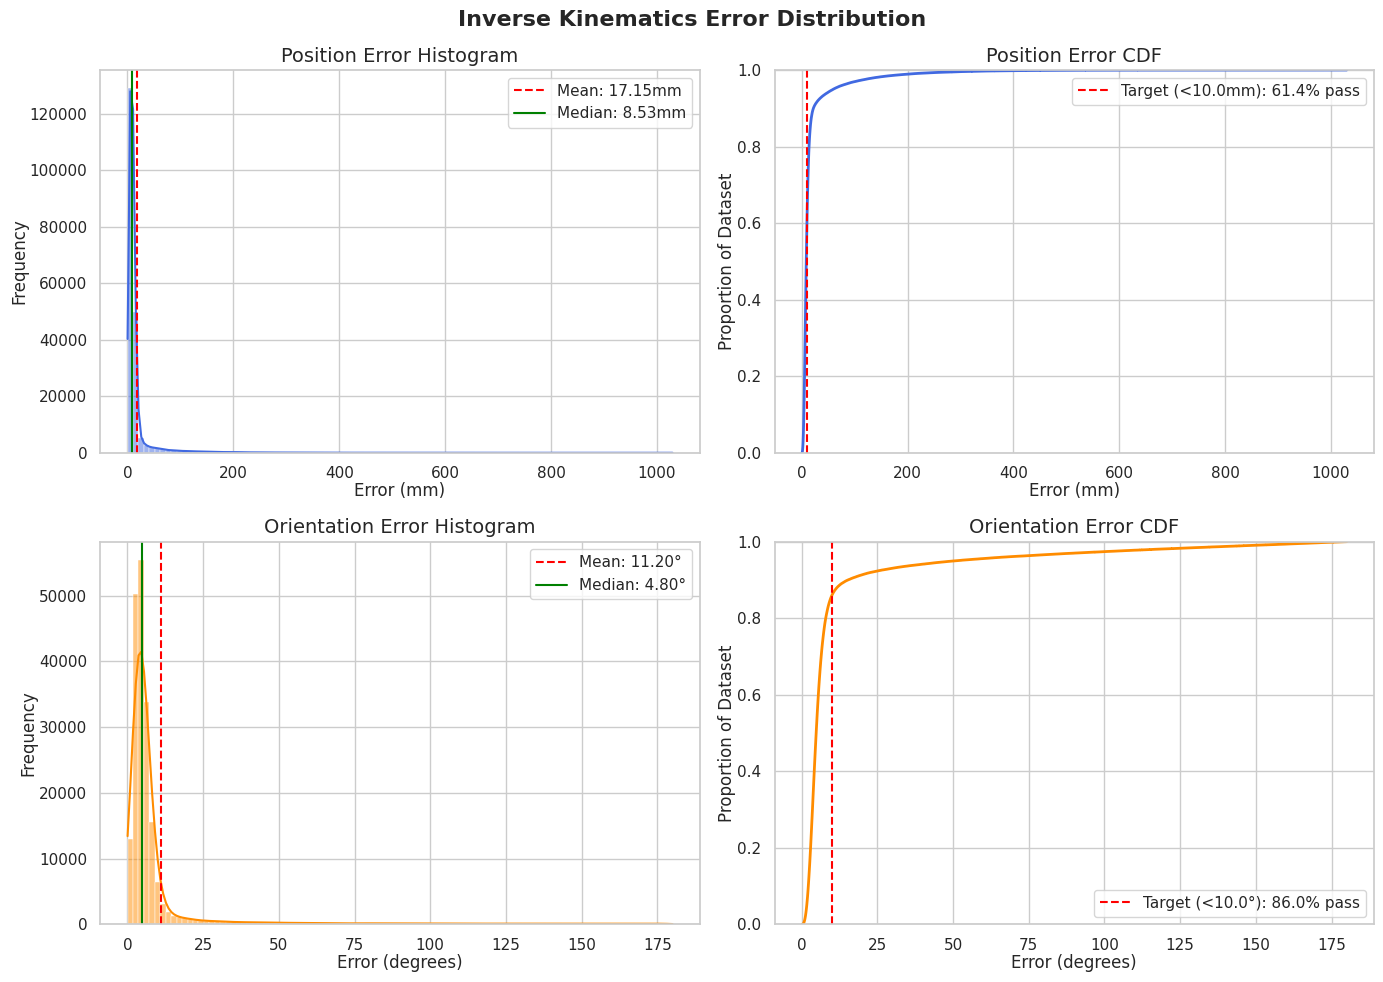

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_ik_errors(plot_data, pos_threshold_mm=10.0, ori_threshold_deg=10.0):
    """
    Generates histograms and CDF plots for Position and Orientation errors.

    Args:
        plot_data: Dictionary returned by evaluate_ur3_kinematics().
        pos_threshold_mm: Target success threshold for position (draws a red line).
        ori_threshold_deg: Target success threshold for orientation (draws a red line).
    """
    pos_errors = plot_data["pos_errors"]
    ori_errors = plot_data["ori_errors"]

    # Set seaborn style for cleaner, academic-looking plots
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Inverse Kinematics Error Distribution', fontsize=16, weight='bold', y=0.98)

    # ==========================================
    # 1. Position Error Histogram
    # ==========================================
    sns.histplot(pos_errors, bins=100, kde=True, ax=axes[0, 0], color="royalblue")
    axes[0, 0].set_title('Position Error Histogram', fontsize=14)
    axes[0, 0].set_xlabel('Error (mm)', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)

    # Add mean/median lines
    axes[0, 0].axvline(np.mean(pos_errors), color='red', linestyle='--', label=f'Mean: {np.mean(pos_errors):.2f}mm')
    axes[0, 0].axvline(np.median(pos_errors), color='green', linestyle='-', label=f'Median: {np.median(pos_errors):.2f}mm')
    axes[0, 0].legend()

    # ==========================================
    # 2. Position Error CDF (Cumulative Distribution)
    # ==========================================
    sns.ecdfplot(pos_errors, ax=axes[0, 1], color="royalblue", linewidth=2)
    axes[0, 1].set_title('Position Error CDF', fontsize=14)
    axes[0, 1].set_xlabel('Error (mm)', fontsize=12)
    axes[0, 1].set_ylabel('Proportion of Dataset', fontsize=12)

    # Add success threshold line
    success_rate = np.mean(pos_errors < pos_threshold_mm)
    axes[0, 1].axvline(pos_threshold_mm, color='red', linestyle='--',
                       label=f'Target (<{pos_threshold_mm}mm): {success_rate*100:.1f}% pass')
    axes[0, 1].legend()

    # ==========================================
    # 3. Orientation Error Histogram
    # ==========================================
    sns.histplot(ori_errors, bins=100, kde=True, ax=axes[1, 0], color="darkorange")
    axes[1, 0].set_title('Orientation Error Histogram', fontsize=14)
    axes[1, 0].set_xlabel('Error (degrees)', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)

    # Add mean/median lines
    axes[1, 0].axvline(np.mean(ori_errors), color='red', linestyle='--', label=f'Mean: {np.mean(ori_errors):.2f}°')
    axes[1, 0].axvline(np.median(ori_errors), color='green', linestyle='-', label=f'Median: {np.median(ori_errors):.2f}°')
    axes[1, 0].legend()

    # ==========================================
    # 4. Orientation Error CDF
    # ==========================================
    sns.ecdfplot(ori_errors, ax=axes[1, 1], color="darkorange", linewidth=2)
    axes[1, 1].set_title('Orientation Error CDF', fontsize=14)
    axes[1, 1].set_xlabel('Error (degrees)', fontsize=12)
    axes[1, 1].set_ylabel('Proportion of Dataset', fontsize=12)

    # Add success threshold line
    ori_success = np.mean(ori_errors < ori_threshold_deg)
    axes[1, 1].axvline(ori_threshold_deg, color='red', linestyle='--',
                       label=f'Target (<{ori_threshold_deg}°): {ori_success*100:.1f}% pass')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Make room for the suptitle
    plt.show()

# --- How to execute it ---
# plot_data = evaluate_ur3_kinematics(inverse_net, test_loader, mode_idx=2)
visualize_ik_errors(results)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb
import spatialmath as sm
from mpl_toolkits.mplot3d import Axes3D

import numpy as np

def generate_circle_trajectory(num_steps=100, radius=0.10, center=(0.3, 0.0, 0.3)):
    """
    Generates a flat 7D circular trajectory in the Y-Z plane.
    """
    t = np.linspace(0, 2 * np.pi, num_steps)
    cx, cy, cz = center

    xs = np.ones_like(t) * cx
    ys = cy + radius * np.cos(t)
    zs = cz + radius * np.sin(t)

    # Tool pointing downward/forward: [qw, qx, qy, qz]
    target_quat = [0.0, 0.707, 0.707, 0.0]

    trajectory = np.zeros((num_steps, 7))
    trajectory[:, :3] = np.stack([xs, ys, zs], axis=1)
    trajectory[:, 3:] = target_quat

    return trajectory


def generate_helix_trajectory(num_steps=120, radius=0.08, center_yz=(0.0, 0.3), x_bounds=(0.22, 0.38)):
    """
    Generates a 3D helical trajectory pulling forward along the X-axis over 2 full turns.
    """
    t = np.linspace(0, 4 * np.pi, num_steps) # 4*pi = 2 complete rotations
    cy, cz = center_yz
    x_start, x_end = x_bounds

    xs = np.linspace(x_start, x_end, num_steps)
    ys = cy + radius * np.cos(t)
    zs = cz + radius * np.sin(t)

    target_quat = [0.0, 0.707, 0.707, 0.0]

    trajectory = np.zeros((num_steps, 7))
    trajectory[:, :3] = np.stack([xs, ys, zs], axis=1)
    trajectory[:, 3:] = target_quat

    return trajectory


def generate_figure8_trajectory(num_steps=100, radius=0.12, center=(0.3, 0.0, 0.3)):
    """
    Generates a 7D Figure-8 (Lemniscate of Bernoulli) trajectory in the Y-Z plane.
    """
    t = np.linspace(0, 2 * np.pi, num_steps)
    cx, cy, cz = center

    xs = np.ones_like(t) * cx
    ys = cy + radius * np.sin(t)
    zs = cz + (radius * np.sin(2 * t)) / 2  # Doubled frequency creates the second loop

    target_quat = [0.0, 0.707, 0.707, 0.0]

    trajectory = np.zeros((num_steps, 7))
    trajectory[:, :3] = np.stack([xs, ys, zs], axis=1)
    trajectory[:, 3:] = target_quat

    return trajectory

def explore_latent_trajectory(inverse_net, trajectory_7d, num_classes=8, target_mode=2):
    """
    Evaluates an IK model along a 7D trajectory and generates a 2x2 multi-view subplot
    matrix showing Isometric, Front, Top, and Right task-space projections.
    """
    # 1. Initialize the robot model
    ur3 = rtb.models.UR3()
    inverse_net.eval()
    device = next(inverse_net.parameters()).device

    # 2. Extract dimensions and properties from the 7D input array
    if isinstance(trajectory_7d, torch.Tensor):
        trajectory_np = trajectory_7d.cpu().numpy()
        poses_tensor = trajectory_7d.to(device)
    else:
        trajectory_np = np.array(trajectory_7d, dtype=np.float32)
        poses_tensor = torch.tensor(trajectory_7d, dtype=torch.float32).to(device)

    num_steps = trajectory_np.shape[0]
    gt_pos = trajectory_np[:, :3]
    gt_quats = trajectory_np[:, 3:]

    # 3. Neural Network Inference for the chosen latent mode
    with torch.no_grad():
        z_token = torch.zeros(num_steps, num_classes, device=device)
        z_token[:, target_mode] = 1.0

        predicted_waves = inverse_net(poses_tensor, z_token)
        sin_part = predicted_waves[:, :6]
        cos_part = predicted_waves[:, 6:]
        pred_joints = torch.atan2(sin_part, cos_part).cpu().numpy()

    # 4. Calculate Reached Positions & Orientations via True FK
    pred_pos = []
    pred_R = []
    for q in pred_joints:
        fk_matrix = ur3.fkine(q)
        pred_pos.append(fk_matrix.t)   # Achieved XYZ Position
        pred_R.append(fk_matrix.R)     # Achieved 3x3 Rotation Matrix
    pred_pos = np.array(pred_pos)

    # ---------------------------------------------------------
    # 5. MULTI-VIEW 3D CANVAS GENERATION (2x2 Grid)
    # ---------------------------------------------------------
    fig = plt.figure(figsize=(16, 14))

    # Define the 4 viewing configurations [Elevation, Azimuth]
    view_modes = [
        {"pos": 221, "title": "Isometric Perspective View", "elev": 20, "azim": 45},
        {"pos": 222, "title": "Front View (Y-Z Plane Face)",  "elev": 0,  "azim": 0},
        {"pos": 223, "title": "Top View (X-Y Plane Overlook)", "elev": 90, "azim": -90},
        {"pos": 224, "title": "Right View (X-Z Plane Side)",   "elev": 0,  "azim": -90}
    ]

    # Calculate global structural axis bounds for 1:1:1 consistency across views
    combined_x = np.concatenate([gt_pos[:, 0], pred_pos[:, 0]])
    combined_y = np.concatenate([gt_pos[:, 1], pred_pos[:, 1]])
    combined_z = np.concatenate([gt_pos[:, 2], pred_pos[:, 2]])

    max_span = max(
        combined_x.max() - combined_x.min(),
        combined_y.max() - combined_y.min(),
        combined_z.max() - combined_z.min()
    )
    max_span = max(max_span, 0.25) # Set a baseline buffer floor
    mid_x, mid_y, mid_z = combined_x.mean(), combined_y.mean(), combined_z.mean()

    # Populate the canvas subplots
    for view in view_modes:
        ax = fig.add_subplot(view["pos"], projection='3d')

        # Plot continuous ground-truth path
        ax.plot(gt_pos[:, 0], gt_pos[:, 1], gt_pos[:, 2],
                color='black', linewidth=2, alpha=0.8, label='Planned Target Path')

        # Scatter actual achieved tool points
        ax.scatter(pred_pos[:, 0], pred_pos[:, 1], pred_pos[:, 2],
                   color='crimson', alpha=0.5, s=12, label=f'Achieved (Mode {target_mode})')

        # A. Path Direction Arrow Integration
        arrow_indices = np.linspace(0, num_steps - 2, 8, dtype=int)
        for idx in arrow_indices:
            p1, p2 = gt_pos[idx], gt_pos[idx + 1]
            tangent = (p2 - p1) / np.linalg.norm(p2 - p1)
            ax.quiver(p1[0], p1[1], p1[2], tangent[0]*0.012, tangent[1]*0.012, tangent[2]*0.012,
                      color='black', arrow_length_ratio=0.4, linewidth=1.2, pivot='tail')

        # B. End-Effector Tool Orientation Vector Comparison (Z-Axis approach)
        triad_indices = np.linspace(0, num_steps - 1, 8, dtype=int)
        for i, idx in enumerate(triad_indices):
            # Target Vector (Extracted dynamically from the sample's unique quaternion)
            R_target = sm.UnitQuaternion(gt_quats[idx]).R
            z_axis_gt = R_target[:, 2]
            p_gt = gt_pos[idx]
            ax.quiver(p_gt[0], p_gt[1], p_gt[2], z_axis_gt[0]*0.035, z_axis_gt[1]*0.035, z_axis_gt[2]*0.035,
                      color='royalblue', arrow_length_ratio=0.3, linewidth=1.2,
                      label='Target Tool Z' if i == 0 else "")

            # Predicted Outcome Vector
            z_axis_pred = pred_R[idx][:, 2]
            p_pred = pred_pos[idx]
            ax.quiver(p_pred[0], p_pred[1], p_pred[2], z_axis_pred[0]*0.035, z_axis_pred[1]*0.035, z_axis_pred[2]*0.035,
                      color='darkorange', arrow_length_ratio=0.3, linewidth=1.8,
                      label='Predicted Tool Z' if i == 0 else "")

        # Apply structural bounding cubes to lock aspect proportions 1:1:1
        ax.set_xlim(mid_x - max_span / 2, mid_x + max_span / 2)
        ax.set_ylim(mid_y - max_span / 2, mid_y + max_span / 2)
        ax.set_zlim(mid_z - max_span / 2, mid_z + max_span / 2)
        ax.set_box_aspect((1, 1, 1))

        # View and label configurations
        ax.view_init(elev=view["elev"], azim=view["azim"])
        ax.set_title(view["title"], fontsize=12, pad=10)
        ax.set_xlabel('X (m)', fontsize=9)
        ax.set_ylabel('Y (m)', fontsize=9)
        ax.set_zlabel('Z (m)', fontsize=9)
        ax.grid(True, alpha=0.2)

        # Display the legend only on the first isometric plot to avoid clutter
        if view["pos"] == 221:
            ax.legend(loc='upper left', fontsize=9)

    plt.suptitle(f"Orthographic Projection Analysis: Latent Space Mode {target_mode}", fontsize=15, y=0.96)
    plt.tight_layout()
    plt.show()

Evaluating Circle Trajectory...
multiple end-effectors present, ambiguous, using self.ee_links[0]


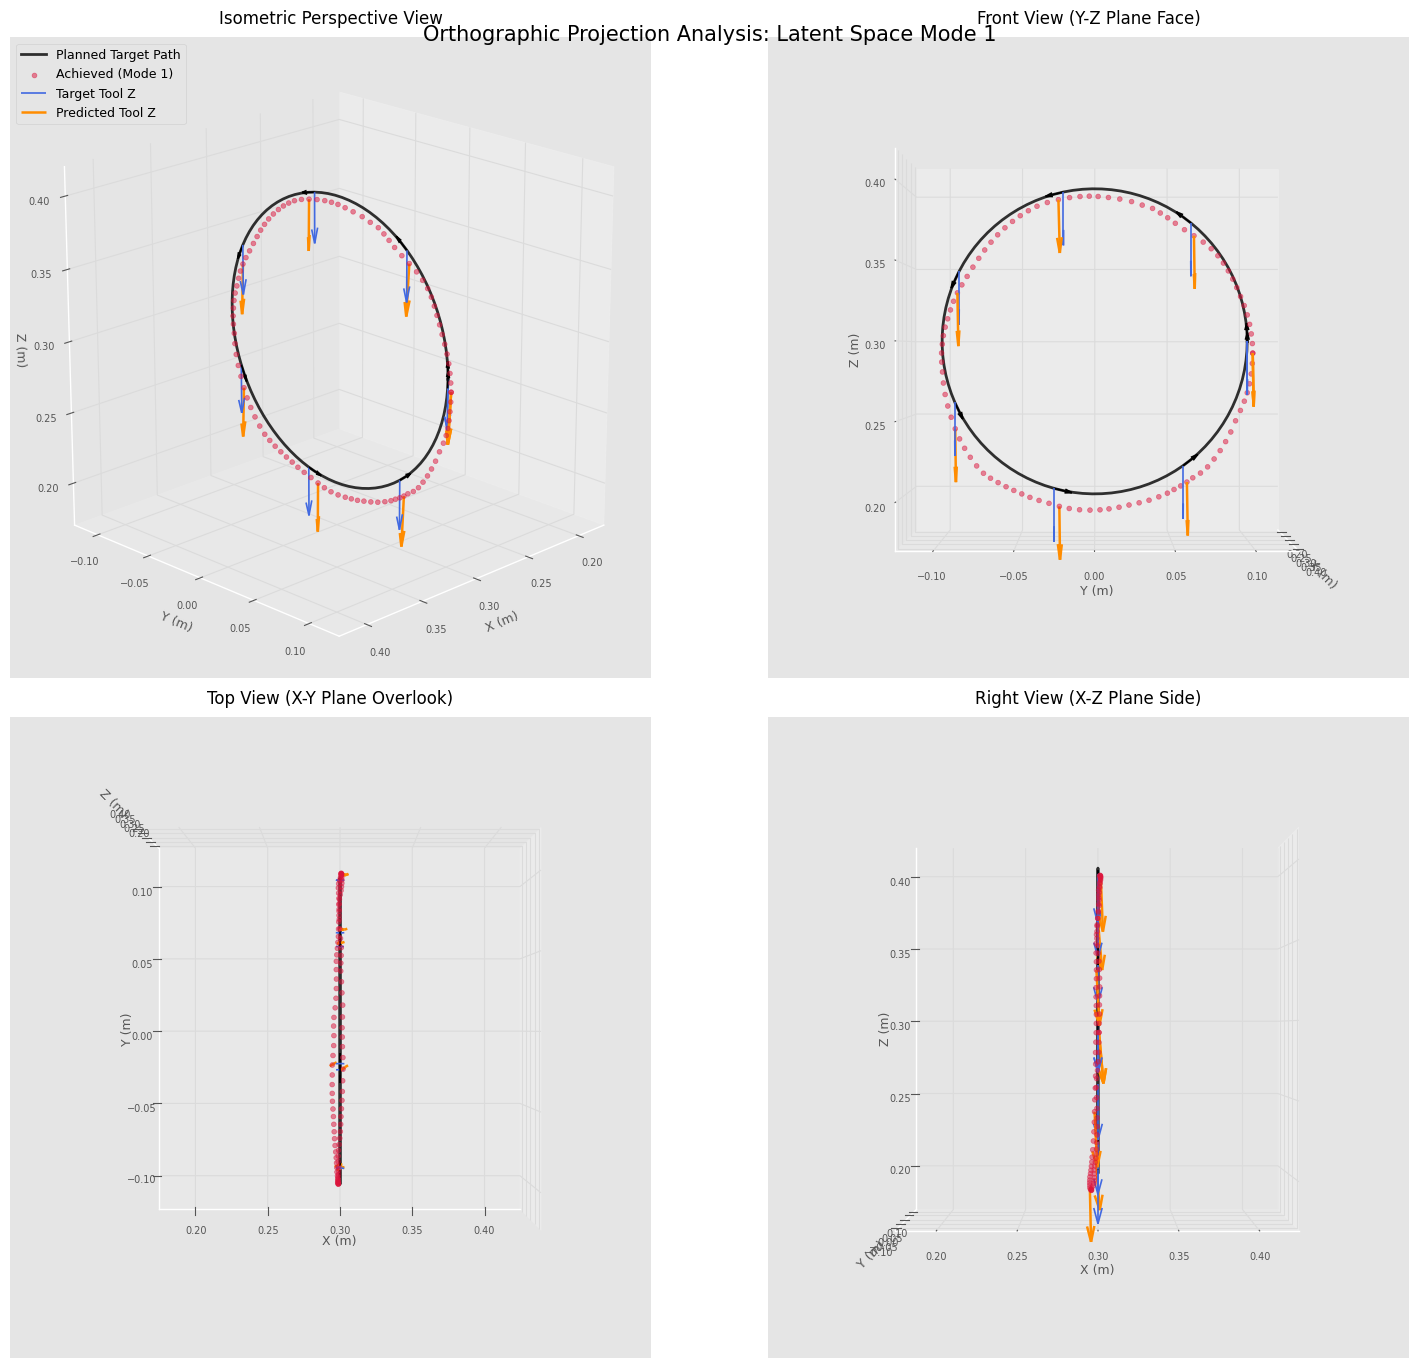

Evaluating Helix Trajectory...
multiple end-effectors present, ambiguous, using self.ee_links[0]


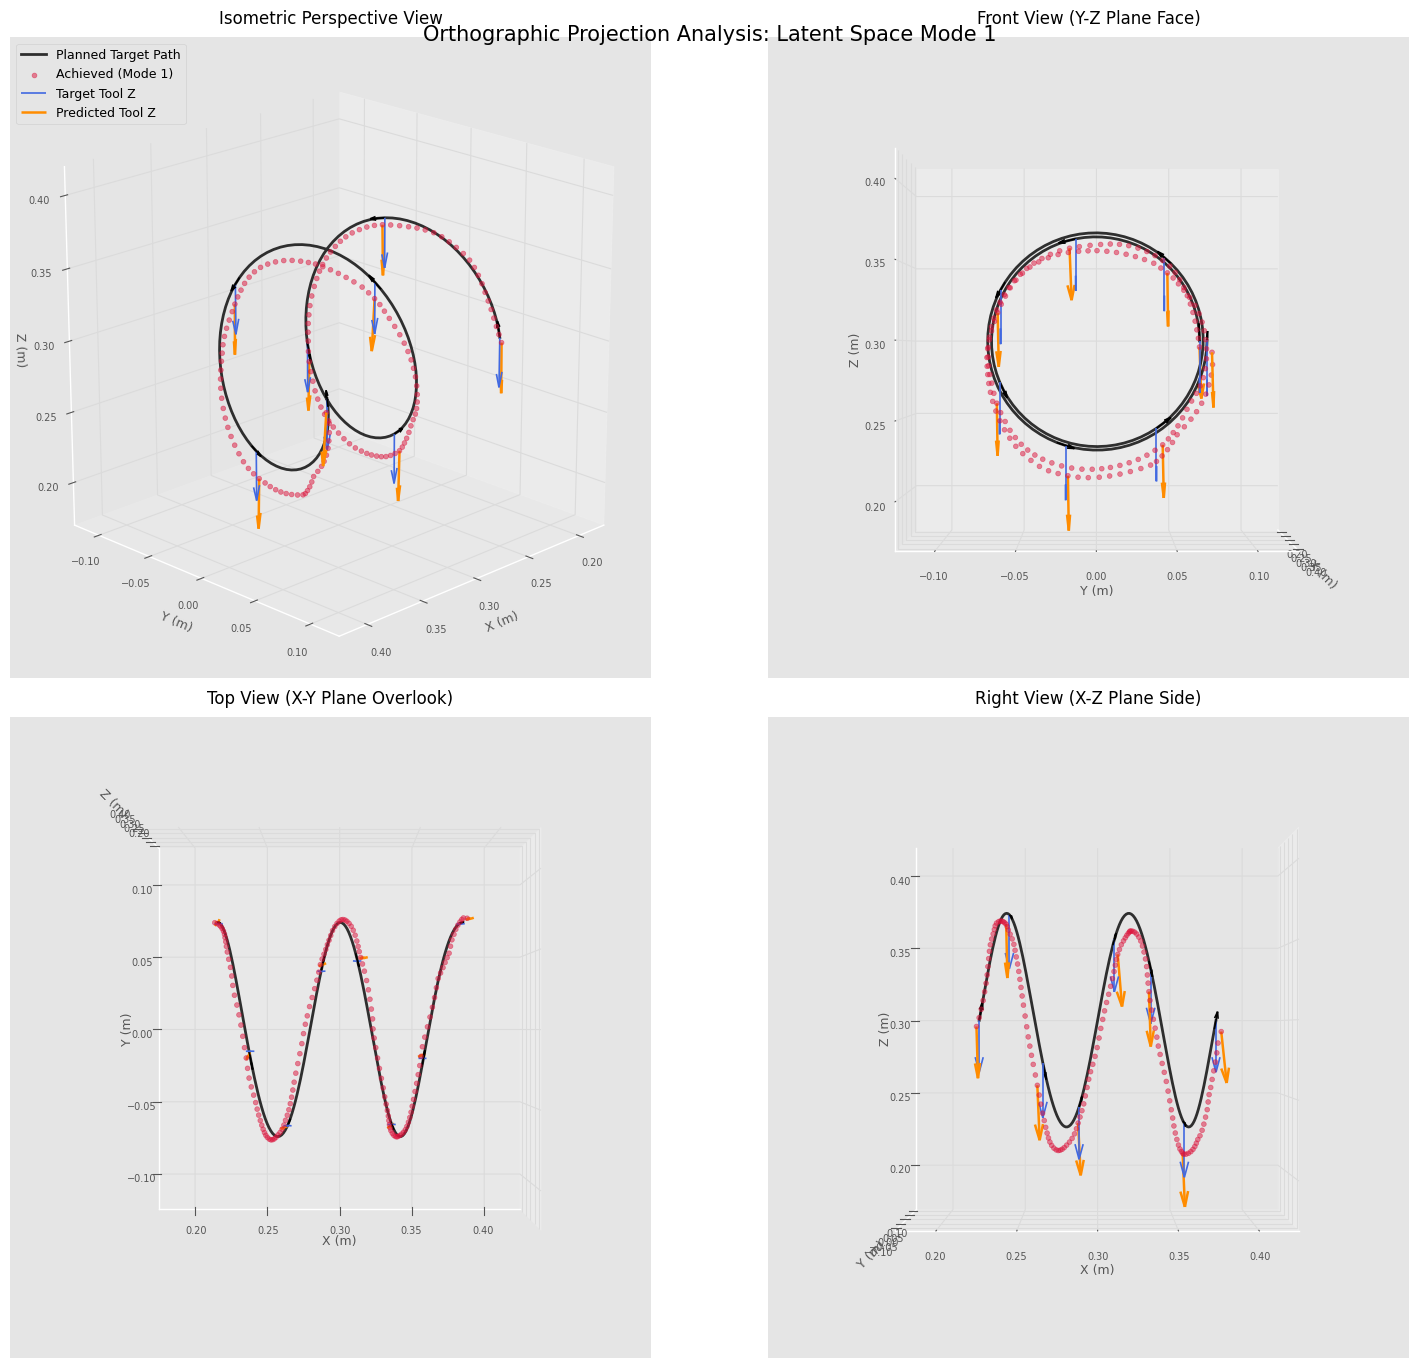

Evaluating Figure-8 Trajectory...
multiple end-effectors present, ambiguous, using self.ee_links[0]


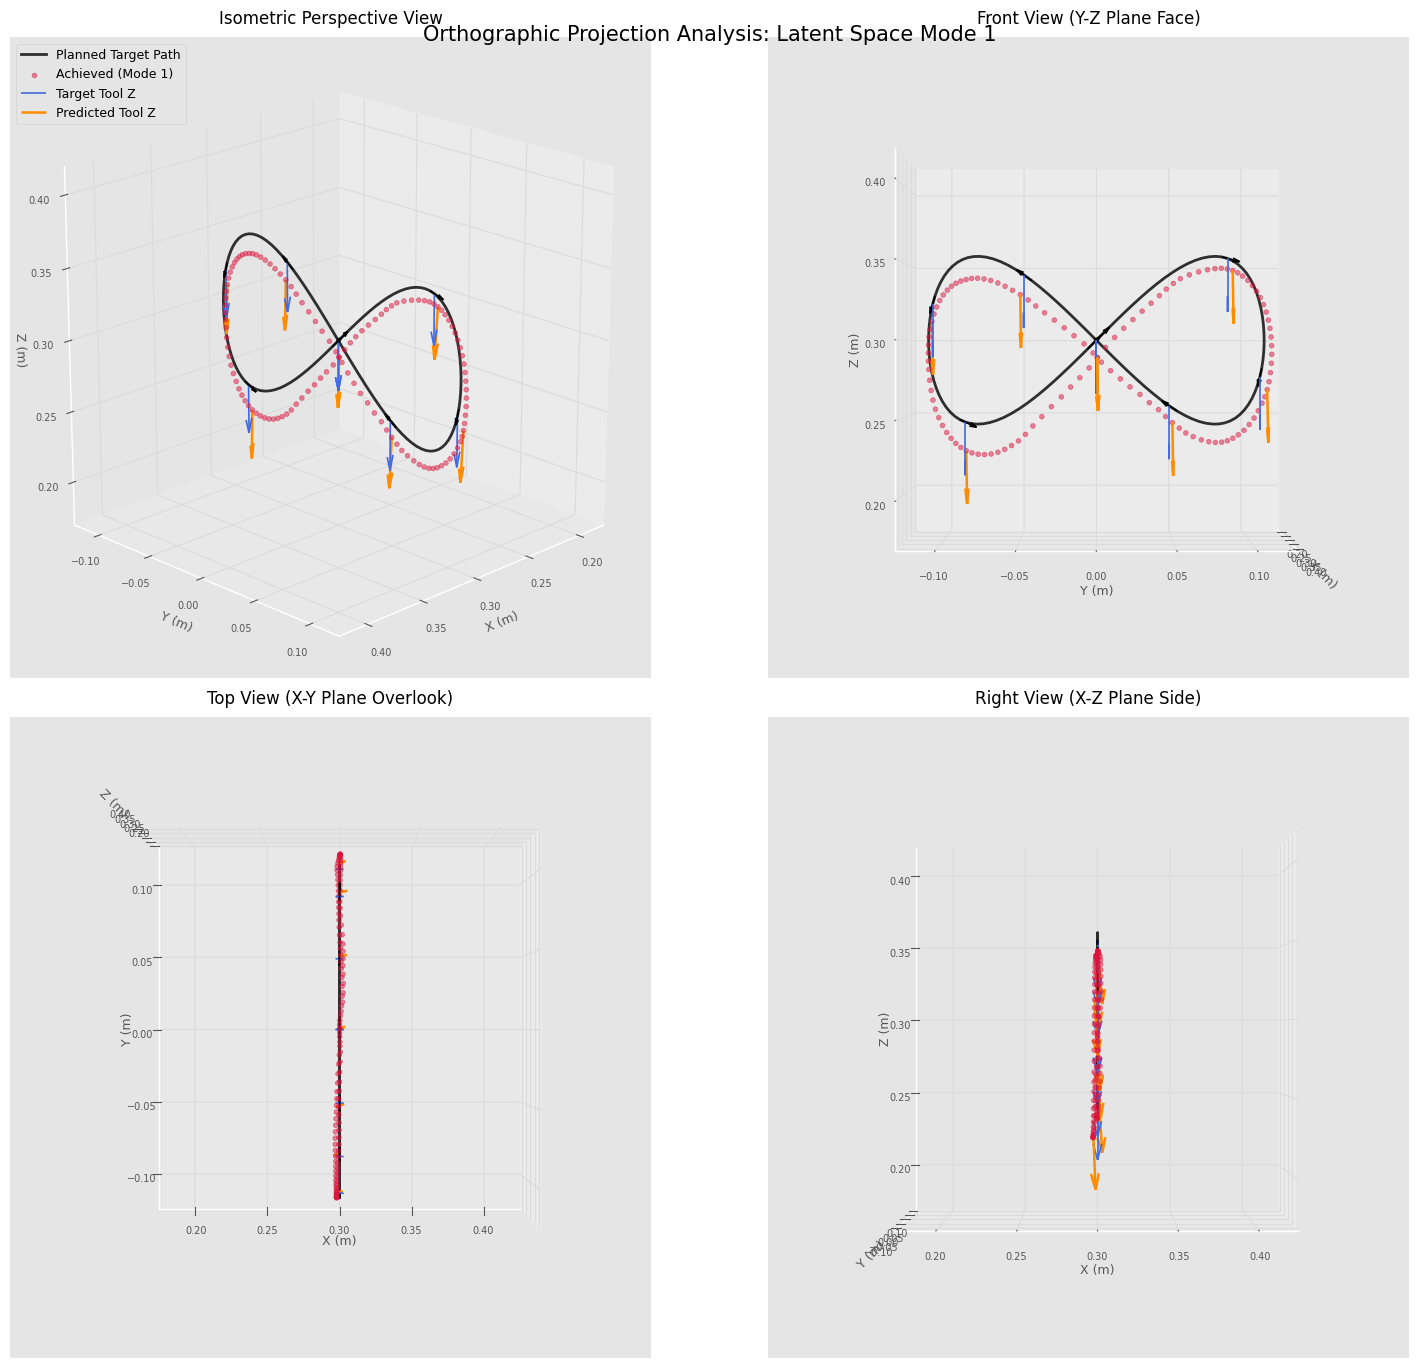

In [ ]:
# 1. Generate the three distinct path arrays
circle_path  = generate_circle_trajectory(num_steps=100, radius=0.10)
helix_path   = generate_helix_trajectory(num_steps=150, radius=0.07)
figure8_path = generate_figure8_trajectory(num_steps=120, radius=0.11)

# 2. Test the Circle (Latent Mode 2)
print("Evaluating Circle Trajectory...")
explore_latent_trajectory(inverse_model, circle_path, num_classes=8, target_mode=1)

# 3. Test the Helix (Latent Mode 2)
print("Evaluating Helix Trajectory...")
explore_latent_trajectory(inverse_model, helix_path, num_classes=8, target_mode=1)

# 4. Test the Figure-8 (Latent Mode 2)
print("Evaluating Figure-8 Trajectory...")
explore_latent_trajectory(inverse_model, figure8_path, num_classes=8, target_mode=1)

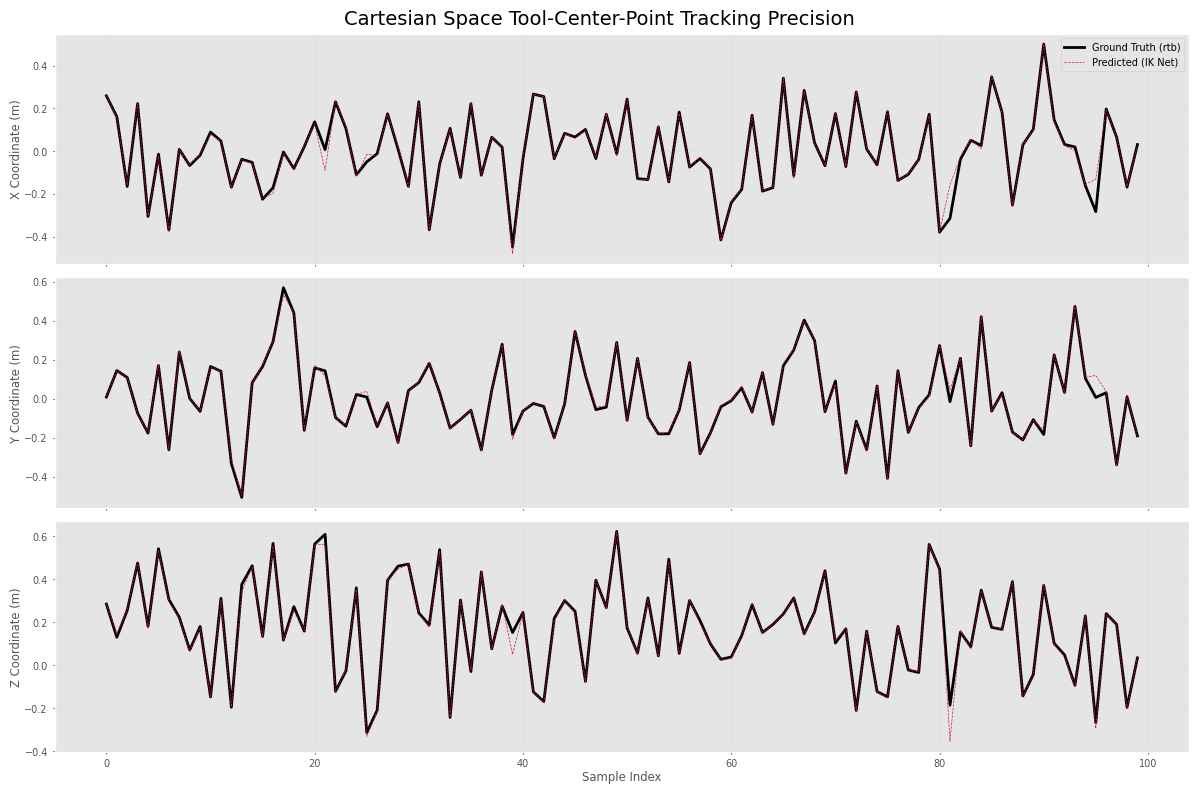

In [ ]:
import matplotlib.pyplot as plt

# We will plot a small subset slice (e.g., 100 points) so the graphs remain readable
num_points_to_plot = 100
gt_pos = results["gt_positions"][:num_points_to_plot]
pred_pos = results["pred_positions"][:num_points_to_plot]
gt_j = results["gt_joints"][:num_points_to_plot]
pred_j = results["pred_joints"][:num_points_to_plot]

# ---------------------------------------------------------
# VISUALIZATION 1: CARTESIAN POSITION TRACKING (XYZ)
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
coords = ['X Coordinate', 'Y Coordinate', 'Z Coordinate']

for i in range(3):
    axes[i].plot(gt_pos[:, i], label='Ground Truth (rtb)', color='black', linewidth=2)
    axes[i].plot(pred_pos[:, i], label='Predicted (IK Net)', color='crimson', linestyle='--')
    axes[i].set_ylabel(f'{coords[i]} (m)')
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend()

axes[2].set_xlabel('Sample Index')
plt.suptitle('Cartesian Space Tool-Center-Point Tracking Precision', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
test_dataset[0]

(tensor([-0.7080, -0.9721, -0.9600, -0.7962,  0.6195,  0.8688, -0.7062,  0.2344,
         -0.2801, -0.6050,  0.7850,  0.4952]),
 tensor([ 0.2584,  0.0089,  0.2850,  0.7056, -0.3736,  0.5079, -0.3235]))

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader, random_split
# from torch.distributions import Normal, Categorical, MixtureSameFamily, Independent
# import pandas as pd
# from sklearn.preprocessing import MinMaxScaler
# import numpy as np

# # ==========================================
# # 1. Prepare the Continuous Dataset
# # ==========================================
# class UR3ContinuousDataset(Dataset):
#     def __init__(self, csv_file):
#         df = pd.read_csv(csv_file)

#         # Inputs: X, Y, Z + Quaternion (qw, qx, qy, qz) -> 7 Dimensions
#         self.X = df[['x', 'y', 'z', 'qw', 'qx', 'qy', 'qz']].values

#         # Outputs: 6 Sines + 6 Cosines -> 12 Dimensions
#         joints = ['base', 'shoulder', 'elbow', 'wrist1', 'wrist2', 'wrist3']
#         sin_cols = [f'sin_{j}' for j in joints]
#         cos_cols = [f'cos_{j}' for j in joints]
#         self.y = df[sin_cols + cos_cols].values

#         # FIX: Use MinMaxScaler(-1, 1) for uniform data instead of StandardScaler
#         self.scaler_X = MinMaxScaler(feature_range=(-1, 1))
#         self.scaler_y = MinMaxScaler(feature_range=(-1, 1))

#         self.X = self.scaler_X.fit_transform(self.X)
#         self.y = self.scaler_y.fit_transform(self.y)

#         # Convert to PyTorch tensors
#         self.X = torch.tensor(self.X, dtype=torch.float32)
#         self.y = torch.tensor(self.y, dtype=torch.float32)

#     def __len__(self):
#         return len(self.X)

#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

# # ==========================================
# # 2. Build the Expanded MDN Architecture
# # ==========================================
# class ContinuousMDN(nn.Module):
#     def __init__(self, input_dim=7, output_dim=12, num_gaussians=6):
#         super(ContinuousMDN, self).__init__()
#         self.input_dim = input_dim
#         self.output_dim = output_dim
#         self.num_gaussians = num_gaussians

#         # FIX: Deeper and wider network to handle 6-DOF Cartesian-to-Joint mapping
#         self.hidden = nn.Sequential(
#             nn.Linear(input_dim, 512),
#             nn.ReLU(),
#             nn.Linear(512, 512),
#             nn.ReLU(),
#             nn.Linear(512, 512),
#             nn.ReLU(),
#             nn.Linear(512, 256),
#             nn.ReLU()
#         )

#         self.pi_head = nn.Linear(256, num_gaussians)
#         self.mu_head = nn.Linear(256, num_gaussians * output_dim)
#         self.sigma_head = nn.Linear(256, num_gaussians * output_dim)

#     def forward(self, x):
#         h = self.hidden(x)

#         # Pi must sum to 1
#         pi = torch.softmax(self.pi_head(h), dim=-1)

#         # Mu is unconstrained
#         mu = self.mu_head(h)
#         mu = mu.view(-1, self.num_gaussians, self.output_dim)

#         # Sigma must be positive
#         sigma = torch.nn.functional.softplus(self.sigma_head(h)) + 1e-6
#         sigma = sigma.view(-1, self.num_gaussians, self.output_dim)

#         return pi, mu, sigma

# # ==========================================
# # 3. Define the MDN Loss Function
# # ==========================================
# def mdn_loss(pi, mu, sigma, y_target):
#     mix = Categorical(probs=pi)

#     base_comp = Normal(loc=mu, scale=sigma)
#     # Treat the 12 output variables as a single multi-dimensional event
#     comp = Independent(base_comp, 1)

#     gmm = MixtureSameFamily(mix, comp)
#     log_prob = gmm.log_prob(y_target)

#     return -log_prob.mean()

In [ ]:
# # Load and Split Data
# full_dataset = UR3ContinuousDataset('ur3_fk_continuous_dataset.csv')

# train_size = int(0.8 * len(full_dataset))
# test_size = len(full_dataset) - train_size
# train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)

In [ ]:
# # ==========================================
# # 4. The GPU Training Loop
# # ==========================================
# from tqdm.auto import tqdm

# if __name__ == "__main__":
#     # Setup Device
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     print(f"Training on device: {device}")

#     print(f"Total parameters to learn: {sum(p.numel() for p in ContinuousMDN().parameters() if p.requires_grad)}")
#     print(f"Training samples: {len(train_dataset)}")

#     # Initialize Model (7 inputs, 12 outputs, 6 peaks)
#     model = ContinuousMDN(input_dim=7, output_dim=12, num_gaussians=6).to(device)
#     optimizer = optim.Adam(model.parameters(), lr=0.001) # Slightly lower LR for stability

#     epochs = 1000
#     print("Starting MDN Training...")

#     for epoch in tqdm(range(epochs), leave=False):
#         model.train()
#         epoch_loss = 0.0

#         for batch_X, batch_y in train_loader:
#             batch_X = batch_X.to(device)
#             batch_y = batch_y.to(device)

#             optimizer.zero_grad()

#             # Forward pass
#             pi, mu, sigma = model(batch_X)

#             # Calculate Loss
#             loss = mdn_loss(pi, mu, sigma, batch_y)

#             # Backpropagation
#             loss.backward()

#             # Gradient clipping
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#             optimizer.step()
#             epoch_loss += loss.item()

#         if (epoch + 1) % 10 == 0:
#             print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_loss/len(train_loader):.4f}")

#     print("Training Complete!")
#     torch.save(model.state_dict(), "ur3_continuous_mdn.pth")

Training on device: cuda
Total parameters to learn: 699286
Training samples: 160000
Starting MDN Training...


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [10/1000] | Train Loss: 2.1980
Epoch [20/1000] | Train Loss: 0.0587
Epoch [30/1000] | Train Loss: -0.9023
Epoch [40/1000] | Train Loss: -1.1253
Epoch [50/1000] | Train Loss: -2.1621
Epoch [60/1000] | Train Loss: -2.4435
Epoch [70/1000] | Train Loss: -2.7778
Epoch [80/1000] | Train Loss: -3.6331
Epoch [90/1000] | Train Loss: -4.6632
Epoch [100/1000] | Train Loss: -5.7804
Epoch [110/1000] | Train Loss: -6.7626
Epoch [120/1000] | Train Loss: -8.0579
Epoch [130/1000] | Train Loss: -8.7766
Epoch [140/1000] | Train Loss: -9.0310
Epoch [150/1000] | Train Loss: -9.9859
Epoch [160/1000] | Train Loss: -10.5404
Epoch [170/1000] | Train Loss: -11.2528
Epoch [180/1000] | Train Loss: -11.5079
Epoch [190/1000] | Train Loss: -11.7989
Epoch [200/1000] | Train Loss: -12.2084
Epoch [210/1000] | Train Loss: -12.2723
Epoch [220/1000] | Train Loss: -12.8260
Epoch [230/1000] | Train Loss: -12.6374
Epoch [240/1000] | Train Loss: -13.3913
Epoch [250/1000] | Train Loss: -13.4699
Epoch [260/1000] | Train L

In [ ]:
# test_loader = DataLoader(test_dataset, batch_size=2048, shuffle=False)

In [ ]:
# import torch
# import numpy as np
# import pandas as pd
# import roboticstoolbox as rtb
# from torch.utils.data import DataLoader, random_split

# # NOTE: You must include your UR3ContinuousDataset and ContinuousMDN classes here
# # so the script knows how to build the objects. (Copy them from the training script).
# # class UR3ContinuousDataset(Dataset): ...
# # class ContinuousMDN(nn.Module): ...

# print("="*50)
# print(" LOADING MODEL AND DATA")
# print("="*50)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # 2. Load the Trained Model
# model = ContinuousMDN(input_dim=7, output_dim=12, num_gaussians=6).to(device)
# # Uncomment the line below once you have actually saved your trained weights
# model.load_state_dict(torch.load("ur3_continuous_mdn.pth", map_location=device))
# model.eval()

# ur3 = rtb.models.UR3()
# all_errors_mm = []
# predictions_data = []

# print("Evaluating on continuous test data...")

# with torch.no_grad():
#     for batch_idx, (test_batch_X, test_batch_y) in enumerate(test_loader):
#         test_batch_X = test_batch_X.to(device)

#         # 3. Get predictions from the MDN
#         pi, mu, sigma = model(test_batch_X)

#         # Find the highest probability peak
#         best_peak_idx = torch.argmax(pi, dim=1)
#         batch_size = mu.size(0)
#         best_mu = mu[torch.arange(batch_size), best_peak_idx, :]

#         # 4. Move to CPU and Inverse Transform (Un-scale)
#         predicted_scaled = best_mu.cpu().numpy()
#         predicted_unscaled = full_dataset.scaler_y.inverse_transform(predicted_scaled)

#         target_X_scaled = test_batch_X.cpu().numpy()
#         target_X_unscaled = full_dataset.scaler_X.inverse_transform(target_X_scaled)

#         # 5. Process the batch
#         for i in range(batch_size):
#             # Extract Target Cartesian (X, Y, Z)
#             target_pos = target_X_unscaled[i, 0:3]

#             # RECONSTRUCT JOINT ANGLES
#             # The first 6 columns are Sines, the last 6 are Cosines
#             pred_sines = predicted_unscaled[i, 0:6]
#             pred_cosines = predicted_unscaled[i, 6:12]

#             # arctan2 smoothly handles the continuous conversion back to [-pi, pi] radians
#             predicted_q = np.arctan2(pred_sines, pred_cosines)

#             # 6. Check physical accuracy
#             actual_tform = ur3.fkine(predicted_q)
#             actual_pos = actual_tform.t

#             distance_error_mm = np.linalg.norm(target_pos - actual_pos) * 1000
#             all_errors_mm.append(distance_error_mm)

#             # Save data for debugging
#             predictions_data.append({
#                 'target_x': target_pos[0], 'target_y': target_pos[1], 'target_z': target_pos[2],
#                 'pred_base': predicted_q[0], 'pred_shoulder': predicted_q[1], 'pred_elbow': predicted_q[2],
#                 'pred_wrist1': predicted_q[3], 'pred_wrist2': predicted_q[4], 'pred_wrist3': predicted_q[5],
#                 'error_mm': distance_error_mm
#             })

# # ==========================================
# # 7. Print Statistical Summary & Save
# # ==========================================
# results_df = pd.DataFrame(predictions_data)
# results_df.to_csv("ur3_continuous_test_results.csv", index=False)

# all_errors_mm = np.array(all_errors_mm)

# print("\n" + "="*50)
# print(f"Total Test Samples: {len(all_errors_mm)}")
# print(f"Mean Error:   {np.mean(all_errors_mm):.2f} mm")
# print(f"Median Error: {np.median(all_errors_mm):.2f} mm")
# print(f"Min Error:    {np.min(all_errors_mm):.2f} mm")
# print(f"Max Error:    {np.max(all_errors_mm):.2f} mm")

# tolerance_mm = 5.0
# success_rate = (np.sum(all_errors_mm <= tolerance_mm) / len(all_errors_mm)) * 100
# print(f"Success Rate (<= {tolerance_mm}mm): {success_rate:.2f}%")
# print("="*50)

 LOADING MODEL AND DATA
Evaluating on continuous test data...
multiple end-effectors present, ambiguous, using self.ee_links[0]

Total Test Samples: 40000
Mean Error:   63.82 mm
Median Error: 34.27 mm
Min Error:    0.57 mm
Max Error:    503.90 mm
Success Rate (<= 5.0mm): 3.35%
